# 봇 시나리오

RSI 반등 전략과 15분봉 MA 단타 전략을 개념용 그래프로 설명합니다.

In [39]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    try:
        font_manager.findfont(font_name, fallback_to_default=False)
        rcParams["font.family"] = font_name
        break
    except ValueError:
        continue
rcParams["axes.unicode_minus"] = False


def build_rsi_scenario() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = np.arange(14)
    price = np.array([100, 98, 95, 93, 92, 94, 96, 99, 102, 104, 103, 101, 100, 99], dtype=float)
    rsi = np.array([42, 37, 32, 28, 24, 31, 38, 49, 58, 72, 75, 67, 55, 48], dtype=float)
    return x, price, rsi


def build_scalp_scenario() -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x = np.arange(14)
    price = np.array([110, 108, 106, 104, 103, 104, 105, 107, 108, 109, 110, 111, 110, 109], dtype=float)
    ma5 = np.array([109, 108, 107, 106, 104.8, 104.2, 104.9, 105.8, 106.9, 107.9, 108.8, 109.4, 109.6, 109.5])
    ma20 = np.array([112, 111.5, 111, 110.5, 110, 109.5, 109, 108.8, 108.7, 108.6, 108.5, 108.4, 108.3, 108.2])
    return x, price, ma5, ma20


def plot_rsi_strategy(ax_price, ax_rsi) -> None:
    x, price, rsi = build_rsi_scenario()
    buy_idx = 5
    take_profit_idx = 9
    stop_loss_idx = 12

    ax_price.plot(x, price, color="#4c78a8", linewidth=2, label="Price")
    ax_price.scatter(x[buy_idx], price[buy_idx], color="#1f77b4", marker="^", s=90, label="BUY-NEW")
    ax_price.scatter(x[take_profit_idx], price[take_profit_idx], color="#d62728", marker="v", s=90, label="SELL-PROFIT")
    ax_price.scatter(x[stop_loss_idx], price[stop_loss_idx], color="#111111", marker="v", s=90, label="SELL-LOSS")
    ax_price.annotate(
        "RSI 30 상향 돌파\n신규 진입 / 물타기",
        xy=(x[buy_idx], price[buy_idx]),
        xytext=(x[buy_idx] - 2.3, price[buy_idx] + 5),
        arrowprops={"arrowstyle": "->", "lw": 1.2},
        fontsize=10,
    )
    ax_price.annotate(
        "RSI 70 이상 + 수익률 1%+\n익절 매도",
        xy=(x[take_profit_idx], price[take_profit_idx]),
        xytext=(x[take_profit_idx] - 2.2, price[take_profit_idx] + 4),
        arrowprops={"arrowstyle": "->", "lw": 1.2},
        fontsize=10,
    )
    ax_price.annotate(
        "원화 부족 + -10% 이하\n절반 손절",
        xy=(x[stop_loss_idx], price[stop_loss_idx]),
        xytext=(x[stop_loss_idx] - 2.5, price[stop_loss_idx] - 7),
        arrowprops={"arrowstyle": "->", "lw": 1.2},
        fontsize=10,
    )
    ax_price.set_title("RSI Rebound Bot Scenario")
    ax_price.set_ylabel("Price")
    ax_price.grid(True, alpha=0.25)
    ax_price.legend(loc="upper left")

    ax_rsi.plot(x, rsi, color="#ff7f0e", linewidth=2, label="RSI(14)")
    ax_rsi.axhline(30, color="#2ca02c", linestyle="--", linewidth=1.2, label="RSI 30")
    ax_rsi.axhline(70, color="#d62728", linestyle="--", linewidth=1.2, label="RSI 70")
    ax_rsi.scatter(x[buy_idx], rsi[buy_idx], color="#1f77b4", s=70)
    ax_rsi.scatter(x[take_profit_idx], rsi[take_profit_idx], color="#d62728", s=70)
    ax_rsi.set_ylabel("RSI")
    ax_rsi.set_xlabel("Step")
    ax_rsi.set_ylim(0, 100)
    ax_rsi.grid(True, alpha=0.25)
    ax_rsi.legend(loc="upper left")


def plot_scalp_strategy(ax_price, ax_profit) -> None:
    x, price, ma5, ma20 = build_scalp_scenario()
    buy_idx = 6
    sell_idx = 11
    target_price = price[buy_idx] * 1.01

    ax_price.plot(x, price, color="#4c78a8", linewidth=2, label="Price")
    ax_price.plot(x, ma5, color="#9467bd", linewidth=2, label="MA5")
    ax_price.plot(x, ma20, color="#2ca02c", linewidth=2, label="MA20")
    ax_price.scatter(x[buy_idx], price[buy_idx], color="#1f77b4", marker="^", s=90, label="BUY-NEW2-15M")
    ax_price.scatter(x[sell_idx], price[sell_idx], color="#d62728", marker="v", s=90, label="SELL-TARGET-1PCT")
    ax_price.axhline(target_price, color="#d62728", linestyle=":", linewidth=1.2, label="Target +1%")
    ax_price.annotate(
        "MA5 < MA20 상태\n하락 후 반등 시작\n단타 진입",
        xy=(x[buy_idx], price[buy_idx]),
        xytext=(x[buy_idx] - 2.5, price[buy_idx] + 5.5),
        arrowprops={"arrowstyle": "->", "lw": 1.2},
        fontsize=10,
    )
    ax_price.annotate(
        "평균단가 대비 +1%\n목표가 익절",
        xy=(x[sell_idx], price[sell_idx]),
        xytext=(x[sell_idx] - 1.8, price[sell_idx] + 4.5),
        arrowprops={"arrowstyle": "->", "lw": 1.2},
        fontsize=10,
    )
    ax_price.set_title("15m MA Scalp Bot Scenario")
    ax_price.set_ylabel("Price")
    ax_price.grid(True, alpha=0.25)
    ax_price.legend(loc="upper left")

    profit_curve = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.45, 0.7, 0.9, 1.0, 1.0, 1.0])
    ax_profit.plot(x, profit_curve, color="#2ca02c", linewidth=2, label="Profit %")
    ax_profit.axhline(0, color="#7f7f7f", linestyle="--", linewidth=1)
    ax_profit.scatter(x[buy_idx], profit_curve[buy_idx], color="#1f77b4", s=70)
    ax_profit.scatter(x[sell_idx], profit_curve[sell_idx], color="#d62728", s=70)
    ax_profit.set_ylabel("Profit %")
    ax_profit.set_xlabel("Step")
    ax_profit.grid(True, alpha=0.25)
    ax_profit.legend(loc="upper left")


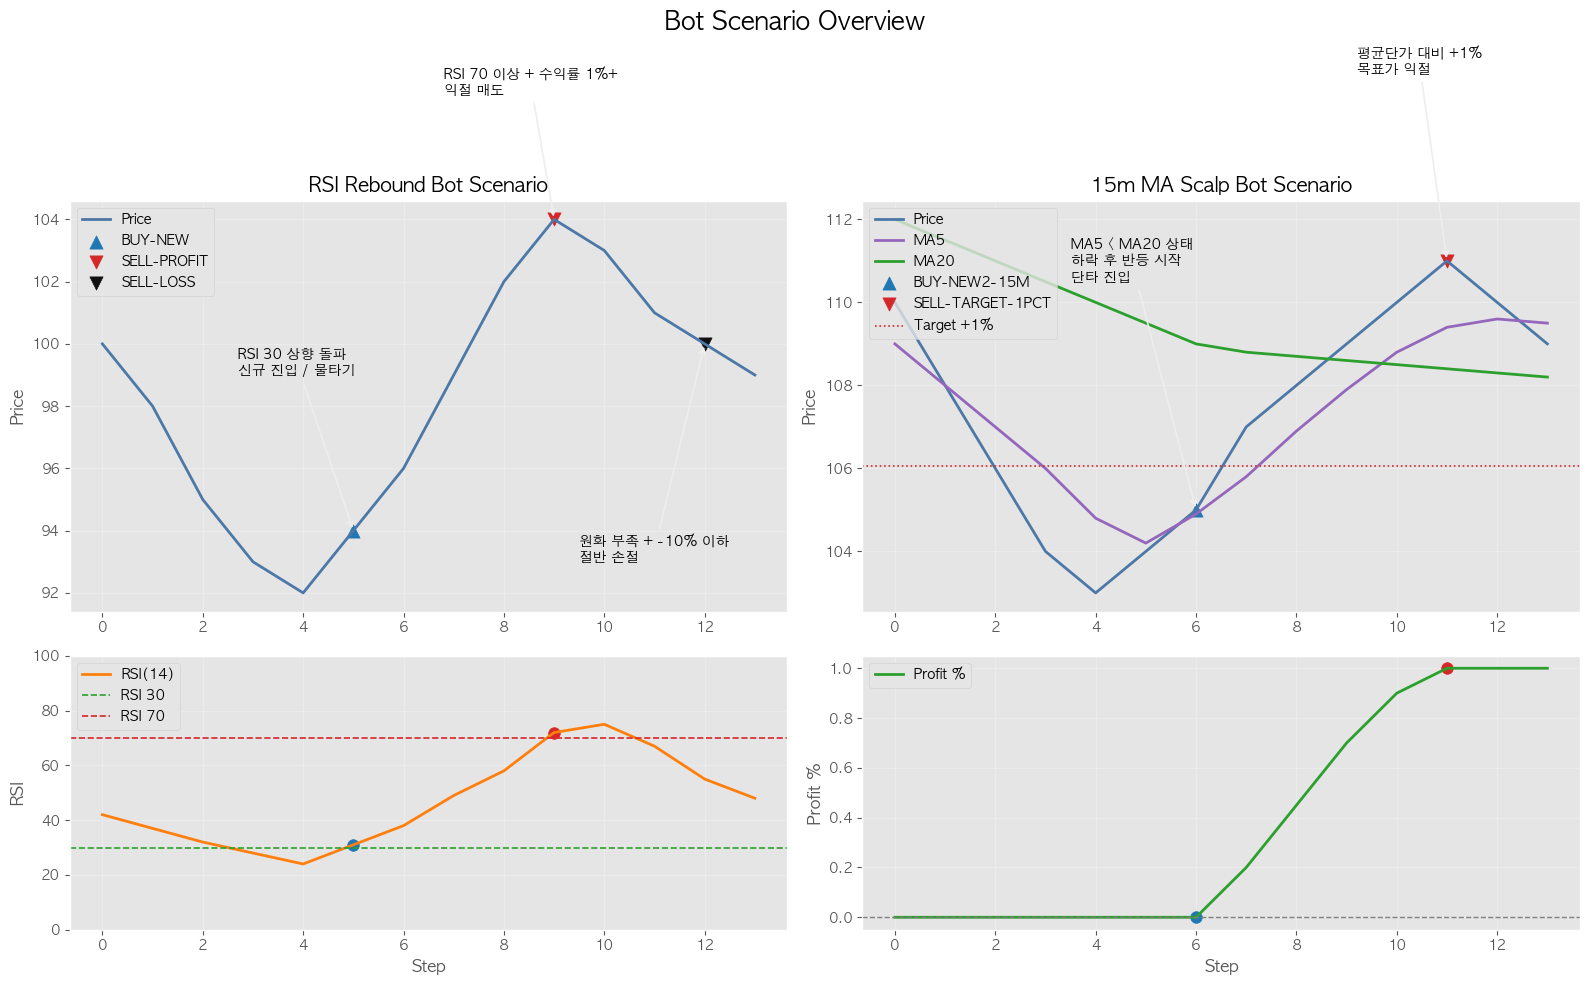

In [40]:
plt.style.use("ggplot")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 2]})

plot_rsi_strategy(axes[0, 0], axes[1, 0])
plot_scalp_strategy(axes[0, 1], axes[1, 1])

fig.suptitle("Bot Scenario Overview", fontsize=18)
plt.tight_layout()
plt.show()


In [41]:
def plot_case_on_axes(ax_price, ax_aux, x, price, aux, title, aux_label, notes, buy_points=None, sell_points=None, extra_lines=None):
    buy_points = buy_points or []
    sell_points = sell_points or []
    extra_lines = extra_lines or []

    ax_price.plot(x, price, color="#4c78a8", linewidth=2, label="가격")
    for idx, label, reason, color in buy_points:
        ax_price.scatter(x[idx], price[idx], color=color, marker="^", s=80, zorder=3)
        ax_price.annotate(
            f"{label}\n{reason}",
            xy=(x[idx], price[idx]),
            xytext=(x[idx] - 1.0, price[idx] + 2.5),
            arrowprops={"arrowstyle": "->", "lw": 0.9},
            fontsize=8,
        )
    for idx, label, reason, color in sell_points:
        ax_price.scatter(x[idx], price[idx], color=color, marker="v", s=80, zorder=3)
        ax_price.annotate(
            f"{label}\n{reason}",
            xy=(x[idx], price[idx]),
            xytext=(x[idx] - 1.0, price[idx] + 2.5),
            arrowprops={"arrowstyle": "->", "lw": 0.9},
            fontsize=8,
        )
    for value, label, color in extra_lines:
        ax_aux.axhline(value, color=color, linestyle="--", linewidth=1.1, label=label)

    ax_price.set_title(title, fontsize=11, weight="bold")
    ax_price.set_ylabel("가격")
    ax_price.grid(True, alpha=0.25)
    ax_price.text(
        0.01,
        0.02,
        notes,
        transform=ax_price.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )

    aux_color = "#ff7f0e" if aux_label.startswith("RSI") else "#2ca02c"
    ax_aux.plot(x, aux, color=aux_color, linewidth=2, label=aux_label)
    ax_aux.set_ylabel(aux_label)
    ax_aux.grid(True, alpha=0.25)
    ax_aux.legend(loc="upper left", fontsize=8)


def build_rsi_cases():
    return [
        {
            "title": "RSI 신규 진입 - BUY-NEW",
            "price": np.array([100, 98, 95, 93, 92, 94, 96, 98, 101, 103], dtype=float),
            "aux": np.array([44, 38, 31, 27, 24, 32, 39, 48, 57, 66], dtype=float),
            "aux_label": "RSI",
            "notes": "이전 RSI <= 30, 현재 RSI > 30, 미보유, 보유 코인 수 < 5",
            "buy_points": [(5, "BUY-NEW", "RSI 30 상향", "#1f77b4")],
            "sell_points": [],
            "extra_lines": [(30, "RSI 30", "#2ca02c"), (70, "RSI 70", "#d62728")],
            "aux_ylim": (0, 100),
        },
        {
            "title": "RSI 일반 물타기 - BUY-WATER-1",
            "price": np.array([108, 104, 101, 99, 97, 98, 100, 102, 103, 104], dtype=float),
            "aux": np.array([46, 35, 30, 28, 26, 31, 37, 45, 52, 58], dtype=float),
            "aux_label": "RSI",
            "notes": "보유 중, 비중 <= 50%, RSI 30 상향 돌파",
            "buy_points": [(5, "BUY-WATER-1", "30 재돌파 + 비중<=50%", "#17becf")],
            "sell_points": [],
            "extra_lines": [(30, "RSI 30", "#2ca02c"), (70, "RSI 70", "#d62728")],
            "aux_ylim": (0, 100),
        },
        {
            "title": "RSI 제한 물타기 - BUY-WATER-2",
            "price": np.array([112, 107, 103, 100, 98, 99, 101, 102, 103, 104], dtype=float),
            "aux": np.array([42, 36, 31, 28, 25, 31, 35, 43, 49, 55], dtype=float),
            "aux_label": "RSI",
            "notes": "보유 중, 비중 > 50%, 수익률 <= -5%, RSI 30 상향 돌파",
            "buy_points": [(5, "BUY-WATER-2", "30 재돌파 + 손실 -5%", "#0d6efd")],
            "sell_points": [],
            "extra_lines": [(30, "RSI 30", "#2ca02c"), (70, "RSI 70", "#d62728")],
            "aux_ylim": (0, 100),
        },
        {
            "title": "RSI 전량 익절 - SELL-PROFIT-ALL",
            "price": np.array([100, 102, 104, 106, 108, 110, 111, 112, 113, 112], dtype=float),
            "aux": np.array([48, 54, 59, 64, 69, 72, 75, 73, 68, 60], dtype=float),
            "aux_label": "RSI",
            "notes": "RSI >= 70, 수익률 >= 1%, 투자금 < 최대 배정금의 25%",
            "buy_points": [],
            "sell_points": [(5, "SELL-PROFIT-ALL", "RSI 70 + 수익 1%", "#d62728")],
            "extra_lines": [(30, "RSI 30", "#2ca02c"), (70, "RSI 70", "#d62728")],
            "aux_ylim": (0, 100),
        },
        {
            "title": "RSI 절반 익절 - SELL-PROFIT-HALF",
            "price": np.array([100, 103, 105, 107, 109, 111, 112, 113, 112, 111], dtype=float),
            "aux": np.array([49, 55, 60, 66, 70, 74, 76, 72, 65, 58], dtype=float),
            "aux_label": "RSI",
            "notes": "RSI >= 70, 수익률 >= 1%, 투자금 >= 최대 배정금의 25%",
            "buy_points": [],
            "sell_points": [(5, "SELL-PROFIT-HALF", "RSI 70 + 분할익절", "#ff7f0e")],
            "extra_lines": [(30, "RSI 30", "#2ca02c"), (70, "RSI 70", "#d62728")],
            "aux_ylim": (0, 100),
        },
        {
            "title": "RSI 절반 손절 - SELL-LOSS-HALF",
            "price": np.array([110, 108, 105, 102, 99, 96, 95, 94, 93, 92], dtype=float),
            "aux": np.array([51, 47, 43, 40, 37, 34, 32, 30, 28, 27], dtype=float),
            "aux_label": "RSI",
            "notes": "남은 원화 < 물탈돈, 수익률 <= -10%",
            "buy_points": [],
            "sell_points": [(6, "SELL-LOSS-HALF", "원화부족 + 손실 -10%", "#111111")],
            "extra_lines": [(30, "RSI 30", "#2ca02c"), (70, "RSI 70", "#d62728")],
            "aux_ylim": (0, 100),
        },
        {
            "title": "RSI 대기 - WAIT",
            "price": np.array([100, 101, 102, 101, 100, 101, 102, 103, 102, 101], dtype=float),
            "aux": np.array([45, 47, 50, 49, 48, 46, 47, 49, 50, 48], dtype=float),
            "aux_label": "RSI",
            "notes": "RSI 30/70 조건 모두 미충족, 주문 없음",
            "buy_points": [],
            "sell_points": [],
            "extra_lines": [(30, "RSI 30", "#2ca02c"), (70, "RSI 70", "#d62728")],
            "aux_ylim": (0, 100),
        },
    ]


def build_scalp_cases():
    return [
        {
            "title": "단타 진입 - BUY-NEW2-15M",
            "price": np.array([110, 108, 106, 104, 103, 104, 105, 107, 108, 109], dtype=float),
            "aux": np.array([0.8, 0.6, 0.3, -0.2, -0.6, -0.4, -0.1, 0.2, 0.5, 0.8], dtype=float),
            "aux_label": "MA5-MA20",
            "notes": "MA5 < MA20 상태, MA5가 하락 후 반등 시작, 미보유, 보유 코인 수 < 5",
            "buy_points": [(6, "BUY-NEW2-15M", "MA5 반등 시작", "#1f77b4")],
            "sell_points": [],
            "extra_lines": [(0, "MA5=MA20", "#7f7f7f")],
            "aux_ylim": None,
        },
        {
            "title": "단타 익절 - SELL-TARGET-1PCT",
            "price": np.array([105, 104, 103, 104, 105, 106, 106.5, 107, 107.2, 107.1], dtype=float),
            "aux": np.array([-0.5, -0.6, -0.4, -0.2, -0.1, 0.1, 0.3, 0.5, 0.6, 0.5], dtype=float),
            "aux_label": "MA5-MA20",
            "notes": "매수 후 평균단가 대비 +1% 목표가 도달",
            "buy_points": [],
            "sell_points": [(7, "SELL-TARGET-1PCT", "목표수익 +1%", "#d62728")],
            "extra_lines": [(0, "MA5=MA20", "#7f7f7f")],
            "aux_ylim": None,
        },
        {
            "title": "단타 홀드 - HOLD",
            "price": np.array([105, 104, 103, 104, 104.5, 104.8, 105.0, 105.1, 104.9, 104.7], dtype=float),
            "aux": np.array([-0.5, -0.6, -0.4, -0.2, -0.1, 0.1, 0.2, 0.25, 0.2, 0.1], dtype=float),
            "aux_label": "MA5-MA20",
            "notes": "진입은 했지만 +1% 목표가까지는 닿지 않음",
            "buy_points": [(5, "ENTRY", "진입 후 목표가 대기", "#1f77b4")],
            "sell_points": [],
            "extra_lines": [(0, "MA5=MA20", "#7f7f7f")],
            "aux_ylim": None,
        },
        {
            "title": "단타 대기 - WAIT",
            "price": np.array([110, 109, 108, 107, 106, 105, 104, 103, 102, 101], dtype=float),
            "aux": np.array([1.2, 1.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0], dtype=float),
            "aux_label": "MA5-MA20",
            "notes": "MA5 반등 구조가 안 만들어져서 진입 안 함",
            "buy_points": [],
            "sell_points": [],
            "extra_lines": [(0, "MA5=MA20", "#7f7f7f")],
            "aux_ylim": None,
        },
    ]


def show_strategy_storyboard(show_center_divider=False):
    x = np.arange(10)
    rsi_cases = build_rsi_cases()
    scalp_cases = build_scalp_cases()
    row_count = max(len(rsi_cases), len(scalp_cases))

    fig, axes = plt.subplots(
        row_count * 2,
        2,
        figsize=(18, row_count * 4.6),
        gridspec_kw={"height_ratios": [3, 1] * row_count},
        sharex=False,
    )
    fig.suptitle("자동매매 봇 시나리오 - 왼쪽 RSI / 오른쪽 15분봉 단타", fontsize=18, weight="bold", y=0.975)
    fig.text(0.28, 0.948, "RSI 버전", ha="center", va="center", fontsize=14, weight="bold")
    fig.text(0.75, 0.948, "단타 버전", ha="center", va="center", fontsize=14, weight="bold")
    if show_center_divider:
        fig.add_artist(
            plt.Line2D(
                [0.5, 0.5],
                [0.04, 0.94],
                transform=fig.transFigure,
                color="#999999",
                linewidth=1.2,
                linestyle="--",
                alpha=0.8,
            )
        )
    fig.subplots_adjust(hspace=0.38, wspace=0.20)

    for row in range(row_count):
        for col, cases in enumerate([rsi_cases, scalp_cases]):
            ax_price = axes[row * 2][col]
            ax_aux = axes[row * 2 + 1][col]
            if row < len(cases):
                case = cases[row]
                plot_case_on_axes(
                    ax_price,
                    ax_aux,
                    x,
                    case["price"],
                    case["aux"],
                    case["title"],
                    case["aux_label"],
                    case["notes"],
                    buy_points=case["buy_points"],
                    sell_points=case["sell_points"],
                    extra_lines=case["extra_lines"],
                )
                if case["aux_ylim"] is not None:
                    ax_aux.set_ylim(*case["aux_ylim"])
            else:
                ax_price.axis("off")
                ax_aux.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()







/var/folders/d9/xb3pxm293r15sx57hh9pcrh80000gn/T/ipykernel_42024/3619292435.py:235: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


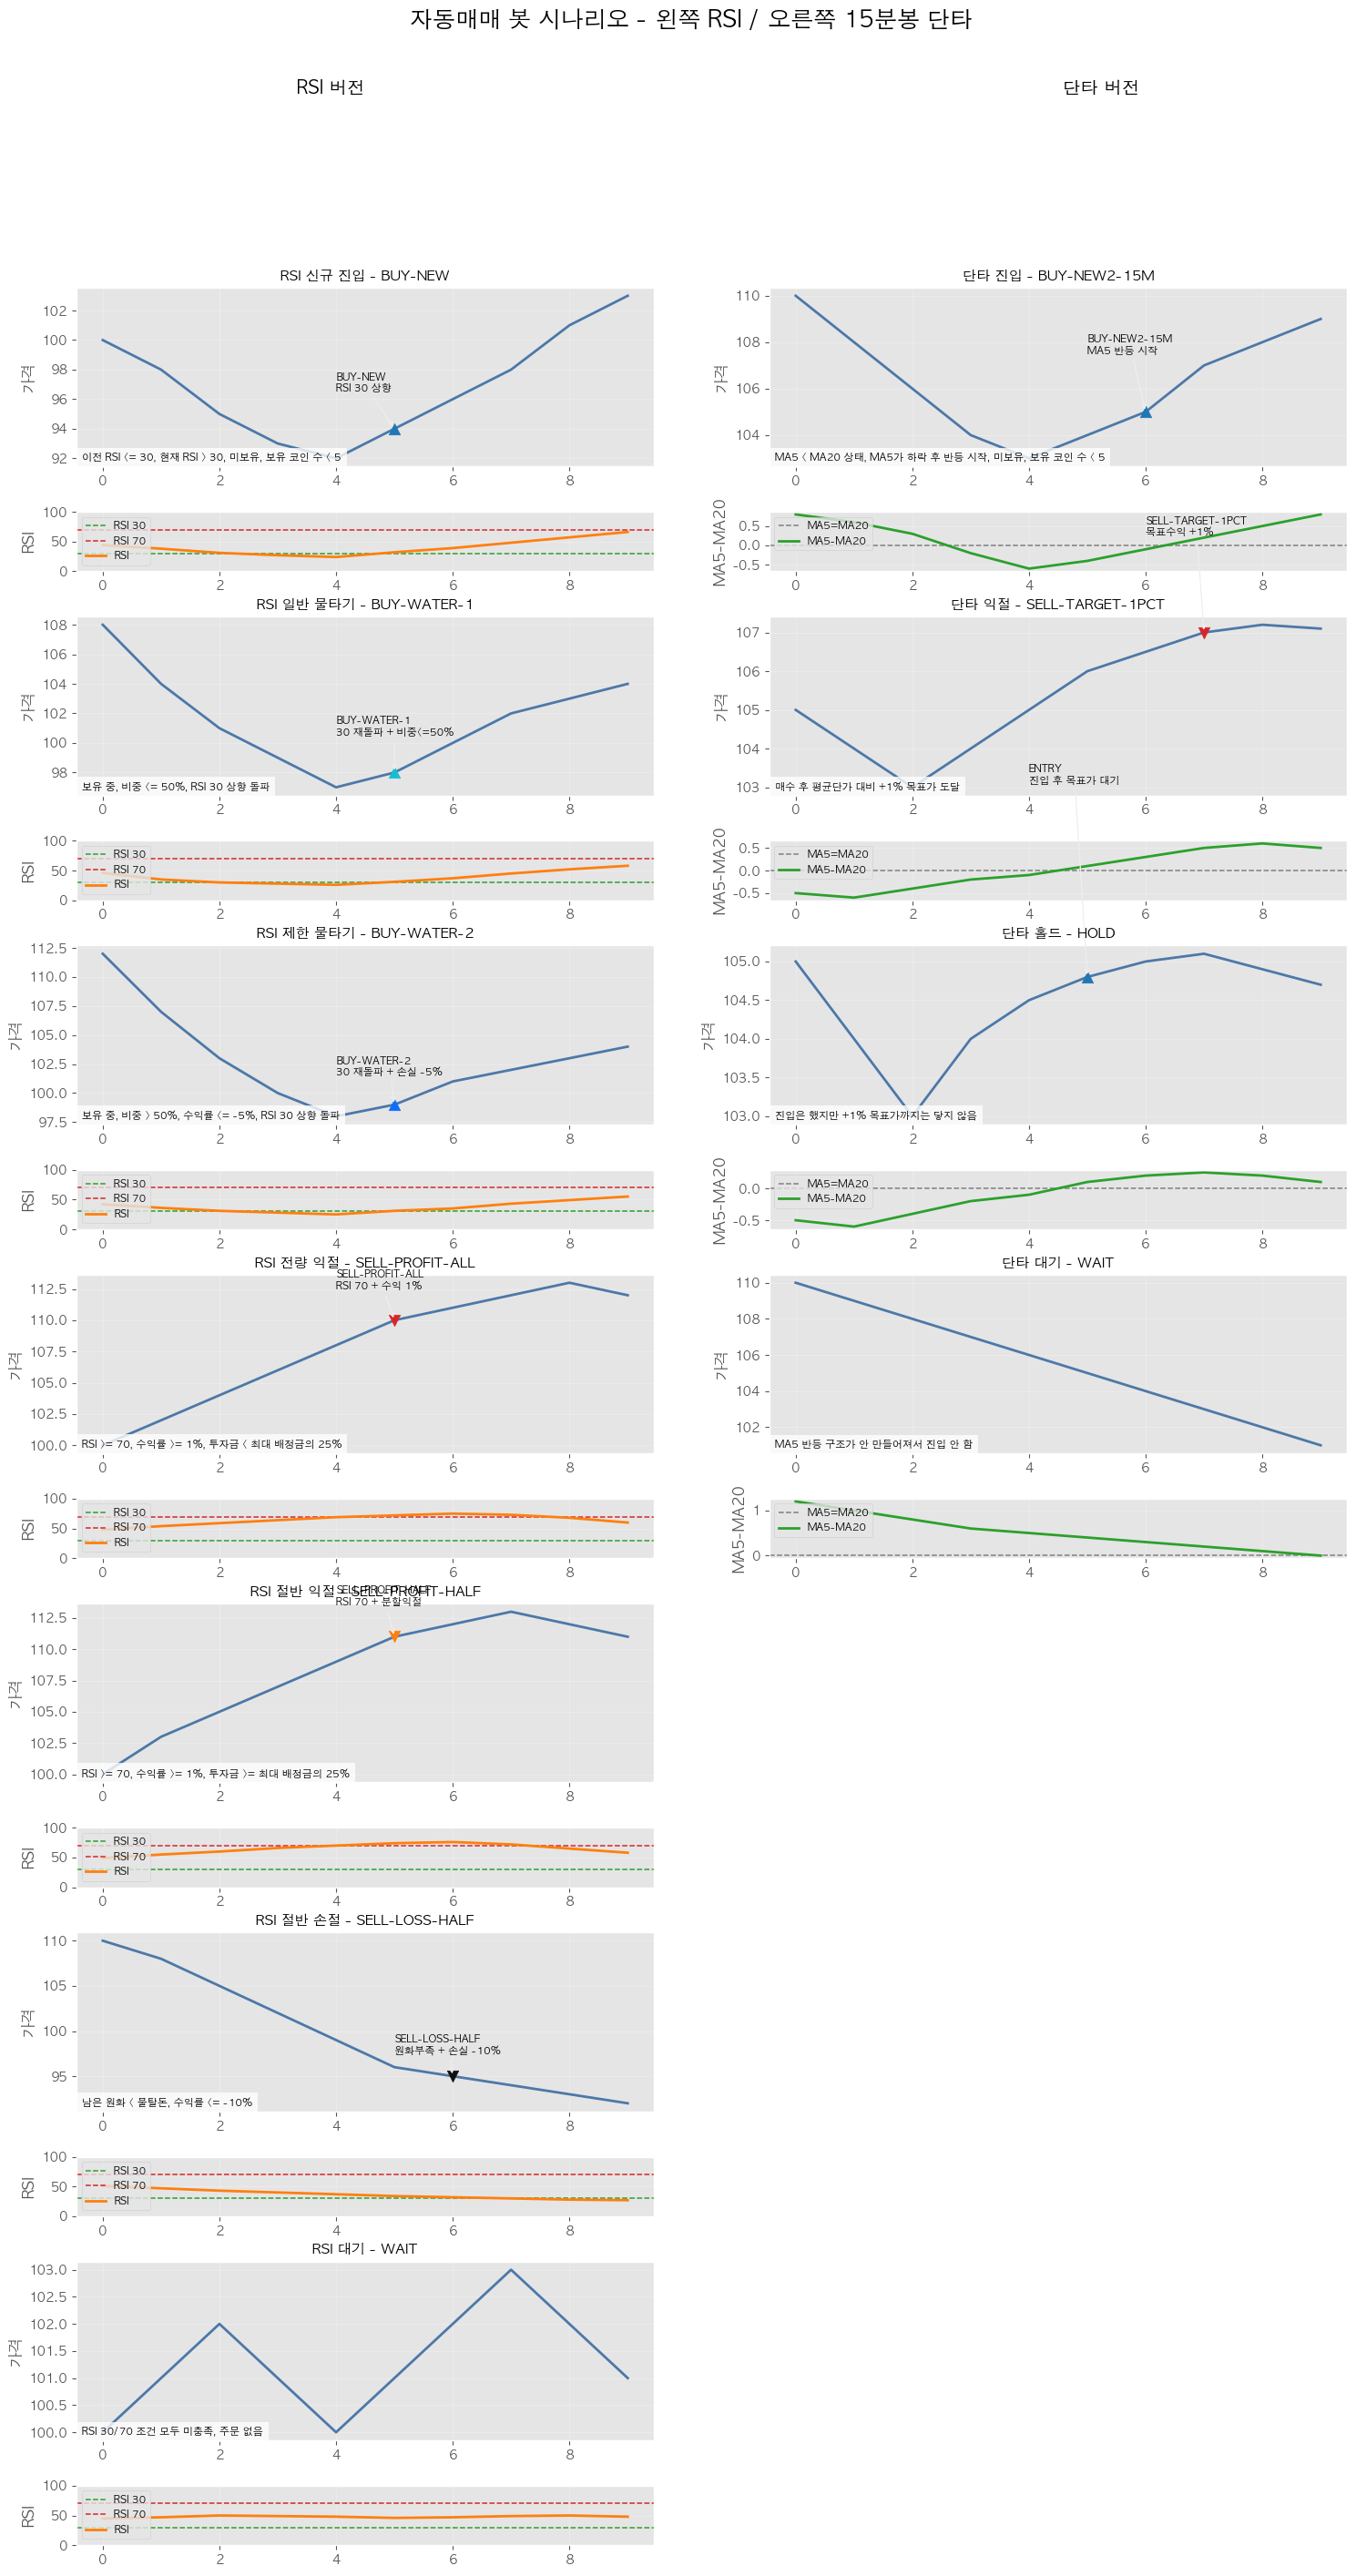

In [ ]:
plt.style.use("ggplot")
SHOW_CENTER_DIVIDER = True

show_strategy_storyboard(show_center_divider=SHOW_CENTER_DIVIDER)

